In [3]:
import zipfile
import os

zip_path = "/content/sensor_readings.zip"
extract_path = "/content/sensor_readings"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['sensor_readings']


In [4]:
for root, dirs, files_ in os.walk(extract_path):
    print(root, len(files_))

/content/sensor_readings 0
/content/sensor_readings/sensor_readings 0
/content/sensor_readings/sensor_readings/place_gasket 6
/content/sensor_readings/sensor_readings/insert_bolt_handtighten 3
/content/sensor_readings/sensor_readings/ignore_for_now 6
/content/sensor_readings/sensor_readings/align_flanges 6
/content/sensor_readings/sensor_readings/clean_inspect 6
/content/sensor_readings/sensor_readings/wrench_tighten 3


In [5]:
import pandas as pd
import numpy as np

DATA_FOLDER = "/content/sensor_readings/sensor_readings"

classes = [
    "clean_inspect",
    "place_gasket",
    "align_flanges",
    "insert_bolt_handtighten",
    "wrench_tighten"
]

all_files = []

for label in classes:
    folder = os.path.join(DATA_FOLDER, label)

    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            path = os.path.join(folder, filename)
            df = pd.read_csv(path)

            all_files.append({
                "label": label,
                "filename": filename,
                "data": df
            })

print("Recordings:", len(all_files))

for item in all_files:
    print(item["label"], item["filename"], len(item["data"]))

Recordings: 24
clean_inspect clean_inspect_03.csv 525
clean_inspect clean_inspect_06.csv 427
clean_inspect clean_inspect_04.csv 466
clean_inspect clean_inspect_02.csv 546
clean_inspect clean_inspect_05.csv 449
clean_inspect clean_inspect_01.csv 624
place_gasket place_gasket_02.csv 693
place_gasket place_gasket_01.csv 601
place_gasket place_gasket_06.csv 589
place_gasket place_gasket_04.csv 763
place_gasket place_gasket_05.csv 561
place_gasket place_gasket_03.csv 627
align_flanges align_flanges_05.csv 804
align_flanges align_flanges_01.csv 1205
align_flanges align_flanges_04.csv 1107
align_flanges align_flanges_06.csv 874
align_flanges align_flanges_03.csv 1101
align_flanges align_flanges_02.csv 1113
insert_bolt_handtighten insert_bolts_hand_tighten_03.csv 3232
insert_bolt_handtighten insert_bolts_hand_tighten_01.csv 4446
insert_bolt_handtighten insert_bolts_hand_tighten_02.csv 3969
wrench_tighten wrench_tighten_02.csv 1582
wrench_tighten wrench_tighten_03.csv 1367
wrench_tighten wrench

In [6]:
SENSOR_COLS = ["ax", "ay", "az", "gx", "gy", "gz"]

TRIM_SAMPLES = 91      # ~2 sec from beginning and end
WINDOW_SIZE = 91       # ~2 sec windows
STEP_SIZE = 45         # ~50% overlap

windows = []

for item in all_files:
    df = item["data"].copy()
    label = item["label"]
    filename = item["filename"]

    # Remove the ~2 sec still period at start and end
    if len(df) > 2 * TRIM_SAMPLES:
        df = df.iloc[
            TRIM_SAMPLES:-TRIM_SAMPLES
        ].reset_index(drop=True)

    sensor_data = df[SENSOR_COLS]

    for start in range(
        0,
        len(sensor_data) - WINDOW_SIZE + 1,
        STEP_SIZE
    ):
        end = start + WINDOW_SIZE

        windows.append({
            "label": label,
            "filename": filename,
            "window": sensor_data.iloc[start:end]
        })

print("Total windows after trimming:", len(windows))

Total windows after trimming: 506


In [7]:
X = np.array([
    item["window"][SENSOR_COLS].values
    for item in windows
], dtype=np.float32)

y = np.array([
    item["label"]
    for item in windows
])

filenames = np.array([
    item["filename"]
    for item in windows
])

print(X.shape)

(506, 91, 6)


In [8]:
val_files = [
    "clean_inspect_06.csv",
    "place_gasket_06.csv",
    "align_flanges_06.csv",
    "insert_bolts_hand_tighten_03.csv",
    "wrench_tighten_03.csv"
]

val_mask = np.isin(filenames, val_files)
train_mask = ~val_mask

X_train = X[train_mask]
X_val = X[val_mask]

y_train_text = y[train_mask]
y_val_text = y[val_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (389, 91, 6)
Validation: (117, 91, 6)


In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train_text)
y_val = encoder.transform(y_val_text)

print(encoder.classes_)

['align_flanges' 'clean_inspect' 'insert_bolt_handtighten' 'place_gasket'
 'wrench_tighten']


In [10]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

X_train_scaled = (X_train - mean) / (std + 1e-8)
X_val_scaled = (X_val - mean) / (std + 1e-8)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2

model_dl = Sequential([
    tf.keras.Input(shape=(100, 6)),

    Conv1D(
        16,
        5,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(
        32,
        3,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),

    GlobalAveragePooling1D(),


    Dropout(0.5),

    Dense(
        len(encoder.classes_),
        activation="softmax"
    )
])

model_dl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model_dl.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - accuracy: 0.3987 - loss: 1.5394 - val_accuracy: 0.3590 - val_loss: 1.5558
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5338 - loss: 1.2800 - val_accuracy: 0.3718 - val_loss: 1.5562
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6527 - loss: 1.0749 - val_accuracy: 0.3333 - val_loss: 1.5800
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7299 - loss: 0.9350 - val_accuracy: 0.3333 - val_loss: 1.6026
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7717 - loss: 0.8455 - val_accuracy: 0.3333 - val_loss: 1.6269
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7846 - loss: 0.7844 - val_accuracy: 0.3333 - val_loss: 1.6409
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7910 - loss: 0.7507 - val_accuracy: 0.3205 - val_loss: 1.6621
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7910 - loss: 0.7267 - val_accuracy: 0.3205 

In [11]:
test_loss, test_accuracy = model_dl.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("CNN Test Accuracy:", test_accuracy)

NameError: name 'X_test_scaled' is not defined

## LSTM

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

model_lstm = Sequential([
    tf.keras.Input(shape=(100, 6)),

    LSTM(
        32,
        return_sequences=False,
        kernel_regularizer=l2(0.001),
        recurrent_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.4),

    Dense(
        len(encoder.classes_),
        activation="softmax"
    )
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,213 (24.27 KB)

 Trainable params: 6,213 (24.27 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# =========================
# TRAIN THE LSTM
# =========================

history_lstm = model_lstm.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint],
    verbose=1)


Epoch 1/100
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2092 - loss: 1.7503
Epoch 1: val_loss improved from None to 1.64230, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2134 - loss: 1.7252 - val_accuracy: 0.1966 - val_loss: 1.6423
Epoch 2/100
22/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2631 - loss: 1.6620
Epoch 2: val_loss improved from 1.64230 to 1.57486, saving model to best_lstm.keras

Epoch 2: finished saving model to best_lstm.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2956 - loss: 1.6635 - val_accuracy: 0.3846 - val_loss: 1.5749
Epoch 3/100
22/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3713 - loss: 1.5509
Epoch 3: val_loss improved from 1.57486 to 1.51108, saving model to best_lstm.keras

Epoch 3: finished saving model to best_lstm.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3573 - loss: 1.5447 - val_accuracy: 0.4701 - val_loss: 1

In [15]:
from tensorflow.keras.models import load_model

best_lstm = load_model("best_lstm.keras")

val_loss, val_accuracy = best_lstm.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Best Validation Loss:", val_loss)
print("Best Validation Accuracy:", val_accuracy)

Best Validation Loss: 1.0729955434799194
Best Validation Accuracy: 0.6410256624221802


In [16]:
import numpy as np
from sklearn.metrics import classification_report

pred_probs = best_lstm.predict(X_val_scaled)
pred_best = np.argmax(pred_probs, axis=1)

print(
    classification_report(
        y_val,
        pred_best,
        target_names=encoder.classes_
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
                         precision    recall  f1-score   support

          align_flanges       0.39      0.50      0.44        14
          clean_inspect       0.19      0.75      0.30         4
insert_bolt_handtighten       0.82      0.85      0.84        66
           place_gasket       0.78      0.88      0.82         8
         wrench_tighten       0.33      0.08      0.13        25

               accuracy                           0.64       117
              macro avg       0.50      0.61      0.51       117
           weighted avg       0.64      0.64      0.62       117



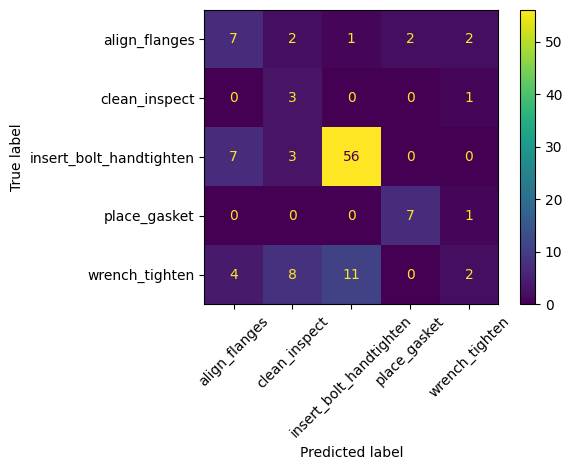

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_best,
    display_labels=encoder.classes_,
    xticks_rotation=45
)

plt.tight_layout()
plt.show()

## CNN LSTM

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization)
from tensorflow.keras.regularizers import l2

model_cnn_lstm = Sequential([tf.keras.Input(shape=(91, 6)),

Conv1D(32, kernel_size=5, activation="relu", padding="same",
           kernel_regularizer=l2(0.001)), BatchNormalization(),

MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),

    MaxPooling1D(pool_size=2),


    LSTM(
        32,
        return_sequences=False,
        kernel_regularizer=l2(0.001),
        recurrent_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.4),

    Dense(
        len(encoder.classes_),
        activation="softmax"
    )
])

model_cnn_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_cnn_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 91, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 91, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 45, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 45, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,221 (82.89 KB)

 Trainable params: 21,029 (82.14 KB)

 Non-trainable params: 192 (768.00 B)

In [16]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint_cnn_lstm = ModelCheckpoint(
    "best_cnn_lstm_accuracy.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [17]:
model_cnn_lstm.fit(
    X_train_scaled,
    y_train,

    validation_data=(X_val_scaled, y_val),

    epochs=80,
    batch_size=32,
    callbacks=[
        checkpoint_cnn_lstm,
    ],

    verbose=1
)

Epoch 1/80
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2709 - loss: 1.8681
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_cnn_lstm_accuracy.keras

Epoch 1: finished saving model to best_cnn_lstm_accuracy.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.2956 - loss: 1.8451 - val_accuracy: 0.2222 - val_loss: 1.8440
Epoch 2/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3715 - loss: 1.6851
Epoch 2: val_accuracy improved from 0.22222 to 0.45299, saving model to best_cnn_lstm_accuracy.keras

Epoch 2: finished saving model to best_cnn_lstm_accuracy.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3882 - loss: 1.6655 - val_accuracy: 0.4530 - val_loss: 1.7358
Epoch 3/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4972 - loss: 1.5381
Epoch 3: val_accuracy improved from 0.45299 to 0.53846, saving model to best_cnn_lstm_accuracy.keras

Epoch 3: finished saving model to best_cnn_lstm_accuracy.keras
13/13 ━━━━━━━━━━━━━━━━━

In [18]:
from tensorflow.keras.models import load_model

best_cnn_lstm = load_model("best_cnn_lstm_accuracy.keras")

In [19]:
val_loss, val_accuracy = best_cnn_lstm.evaluate(
    X_val_scaled,
    y_val,
    verbose=0)

print("CNN-LSTM Validation Loss:", val_loss)
print("CNN-LSTM Validation Accuracy:", val_accuracy)

CNN-LSTM Validation Loss: 1.187666893005371
CNN-LSTM Validation Accuracy: 0.7606837749481201


In [20]:
import numpy as np
from sklearn.metrics import classification_report

pred_probs = best_cnn_lstm.predict(X_val_scaled)
pred_cnn_lstm = np.argmax(pred_probs, axis=1)

print(
    classification_report(
        y_val,
        pred_cnn_lstm,
        target_names=encoder.classes_
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
                         precision    recall  f1-score   support

          align_flanges       0.71      0.71      0.71        14
          clean_inspect       0.30      0.75      0.43         4
insert_bolt_handtighten       0.86      0.95      0.91        66
           place_gasket       0.67      1.00      0.80         8
         wrench_tighten       0.62      0.20      0.30        25

               accuracy                           0.76       117
              macro avg       0.63      0.72      0.63       117
           weighted avg       0.76      0.76      0.73       117



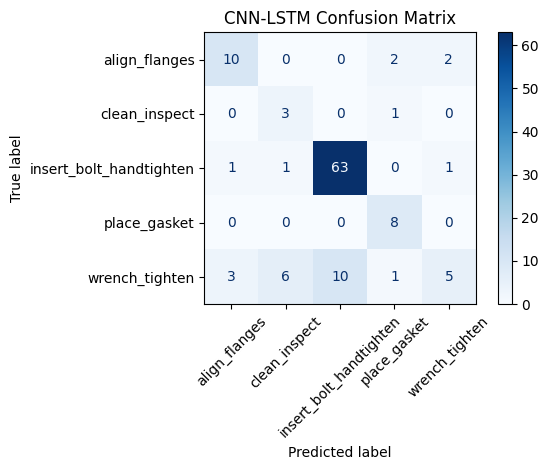

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_cnn_lstm,
    display_labels=encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("CNN-LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

## pre-process

In [22]:
import numpy as np

np.savez(
    "imu_preprocessing.npz",
    mean=mean,
    std=std,
    classes=encoder.classes_
)

print(encoder.classes_)

['align_flanges' 'clean_inspect' 'insert_bolt_handtighten' 'place_gasket'
 'wrench_tighten']


In [23]:
from google.colab import files

files.download("best_cnn_lstm_accuracy.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download("imu_preprocessing.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>